<a href="https://colab.research.google.com/github/PravinV001/Python/blob/Class_N_Colab/Regularisation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

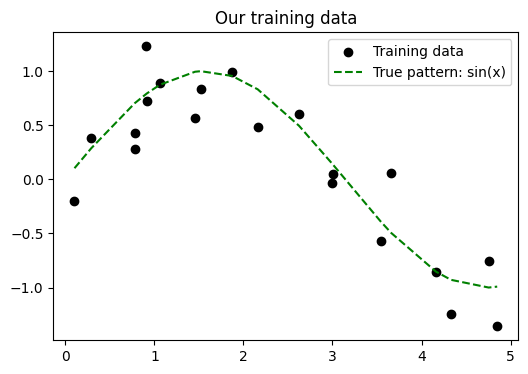

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Let's create some fake data: y = sin(x) + a bit of noise
np.random.seed(42)
X = np.sort(np.random.uniform(0, 5, 20))
y_true = np.sin(X)
y = y_true + np.random.normal(0, 0.3, size=X.shape)   # add noise

plt.figure(figsize=(6,4))
plt.scatter(X, y, color='black', label='Training data')
plt.plot(X, y_true, '--', color='green', label='True pattern: sin(x)')
plt.legend(); plt.title("Our training data")
plt.show()

In [ ]:
degrees = [1, 4, 15]
titles  = ['Degree 1 -> Underfit', 'Degree 4 -> Just right', 'Degree 15 -> Overfit']

In [ ]:
X

array([0.10292247, 0.29041806, 0.7799726 , 0.7800932 , 0.90912484,
       0.91702255, 1.06169555, 1.4561457 , 1.52121121, 1.87270059,
       2.15972509, 2.62378216, 2.99329242, 3.00557506, 3.54036289,
       3.65996971, 4.1622132 , 4.33088073, 4.75357153, 4.84954926])

In [ ]:
poly = PolynomialFeatures(degree=4)

In [ ]:

X_poly = poly.fit_transform(X.reshape(-1,1))

In [ ]:
X_poly.shape

(20, 5)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

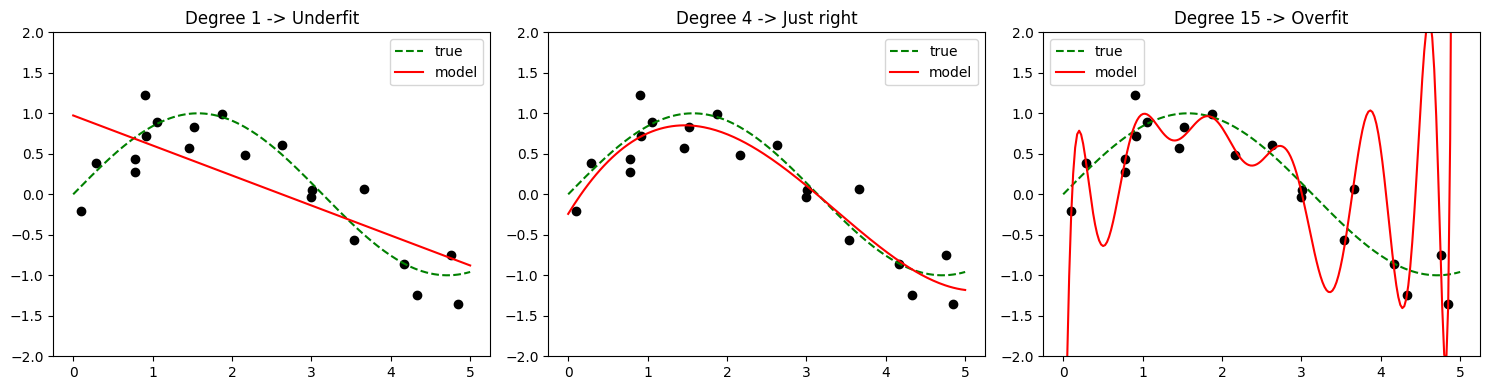

In [ ]:
X_plot = np.linspace(0, 5, 200).reshape(-1,1)

fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, d, title in zip(axes, degrees, titles):
    poly = PolynomialFeatures(degree=d)
    X_poly = poly.fit_transform(X.reshape(-1,1))

    model = LinearRegression()
    model.fit(X_poly, y)

    y_pred_plot = model.predict(poly.transform(X_plot))

    ax.scatter(X, y, color='black')
    ax.plot(X_plot, np.sin(X_plot), '--', color='green', label='true')
    ax.plot(X_plot, y_pred_plot, color='red', label='model')
    ax.set_title(title)
    ax.set_ylim(-2, 2)
    ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
model.coef_

array([ 0.00000000e+00,  7.81136005e+01, -3.49710860e+02,  6.06106513e+02,
       -2.76538998e+02, -3.88612300e+02,  4.34986722e+02,  1.54004022e+02,
       -5.59717531e+02,  4.79764222e+02, -2.29939425e+02,  6.98990548e+01,
       -1.38097545e+01,  1.72485814e+00, -1.24043804e-01,  3.92036102e-03])

In [ ]:
# Let's visualize the bias-variance tradeoff
from sklearn.model_selection import train_test_split

In [ ]:
degrees = range(1, 16)
train_errors, test_errors = [], []

In [ ]:
np.random.seed(0)
X_full = np.sort(np.random.uniform(0, 5, 100))
y_full = np.sin(X_full) + np.random.normal(0, 0.3, 100)

X_tr, X_te, y_tr, y_te = train_test_split(X_full, y_full, test_size=0.3, random_state=1)

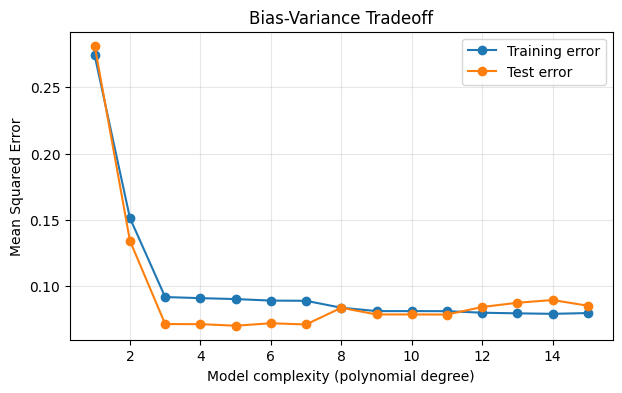

In [ ]:
for d in degrees:
    poly = PolynomialFeatures(degree=d)
    X_tr_p = poly.fit_transform(X_tr.reshape(-1,1))
    X_te_p = poly.transform(X_te.reshape(-1,1))

    model = LinearRegression().fit(X_tr_p, y_tr)
    train_errors.append(np.mean((model.predict(X_tr_p) - y_tr)**2))
    test_errors.append(np.mean((model.predict(X_te_p) - y_te)**2))

plt.figure(figsize=(7,4))
plt.plot(list(degrees), train_errors, 'o-', label='Training error')
plt.plot(list(degrees), test_errors,  'o-', label='Test error')
plt.xlabel('Model complexity (polynomial degree)')
plt.ylabel('Mean Squared Error')
plt.title('Bias-Variance Tradeoff')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

## Mathematical level to prevent overfitting

## Regularisation

### Going back to the loss function

For plain linear regression, we minimize:

$$\text{Loss} = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

This is just "sum of squared errors". The model picks weights $w_1, w_2, \ldots$ to make this as small as possible.

### The regularized version

We add a new term to this loss:

$$\text{New Loss} = \underbrace{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}_{\text{original error}} \;+\; \lambda \underbrace{\sum_{j=1}^{p} w_j^2}_{\text{penalty for big weights}}$$

That's it. We added **λ times the sum of squared weights**.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# Load the data
data = fetch_california_housing()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='price')

print("Shape:", X.shape)
X.head()

Shape: (20640, 8)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


## 10 : 36 pm

In [ ]:
## Train test split
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Scalimg
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)




In [ ]:
## Linear regressin
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)


y_pred_train = lr.predict(X_train_scaled)
y_pred_test  = lr.predict(X_test_scaled)



In [ ]:
print("Linear Regression")
print(f"  Train R2: {r2_score(y_train, y_pred_train):.4f}")
print(f"  Test  R2: {r2_score(y_test,  y_pred_test):.4f}")
print(f"  Train MSE: {mean_squared_error(y_train, y_pred_train):.4f}")
print(f"  Test  MSE: {mean_squared_error(y_test,  y_pred_test):.4f}")

coef_df = pd.DataFrame({'feature': data.feature_names, 'weight': lr.coef_})
print("\nLearned weights:")
print(coef_df)

Linear Regression
  Train R2: 0.6126
  Test  R2: 0.5758
  Train MSE: 0.5179
  Test  MSE: 0.5559

Learned weights:
      feature    weight
0      MedInc  0.854383
1    HouseAge  0.122546
2    AveRooms -0.294410
3   AveBedrms  0.339259
4  Population -0.002308
5    AveOccup -0.040829
6    Latitude -0.896929
7   Longitude -0.869842


In [ ]:
## Ridge Regressionb

In [ ]:
from sklearn.linear_model import  Ridge, Lasso

In [ ]:
## Ridge Regression
ridge = Ridge(alpha=1.0)    # alpha = lambda
ridge.fit(X_train_scaled, y_train)

print("Ridge Regression (alpha=1.0)")
print(f"  Train R2: {ridge.score(X_train_scaled, y_train):.4f}")
print(f"  Test  R2: {ridge.score(X_test_scaled,  y_test):.4f}")   # alpha = lambda

## Lasso Regression

Ridge Regression (alpha=1.0)
  Train R2: 0.6126
  Test  R2: 0.5758


In [ ]:
pd.DataFrame({
    'feature': data.feature_names,
    'Linear weight': lr.coef_,
    'Ridge weight':  ridge.coef_
})

,feature,Linear weight,Ridge weight
0,MedInc,0.854383,0.854327
1,HouseAge,0.122546,0.122624
2,AveRooms,-0.294410,-0.294210
3,AveBedrms,0.339259,0.339008
4,Population,-0.002308,-0.002282
5,AveOccup,-0.040829,-0.040833
6,Latitude,-0.896929,-0.896168
7,Longitude,-0.869842,-0.869071


In [ ]:
alphas = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
weights_over_alpha = []

In [ ]:
for a in alphas:
    r = Ridge(alpha=a).fit(X_train_scaled, y_train)
    weights_over_alpha.append(r.coef_)

weights_over_alpha = np.array(weights_over_alpha)

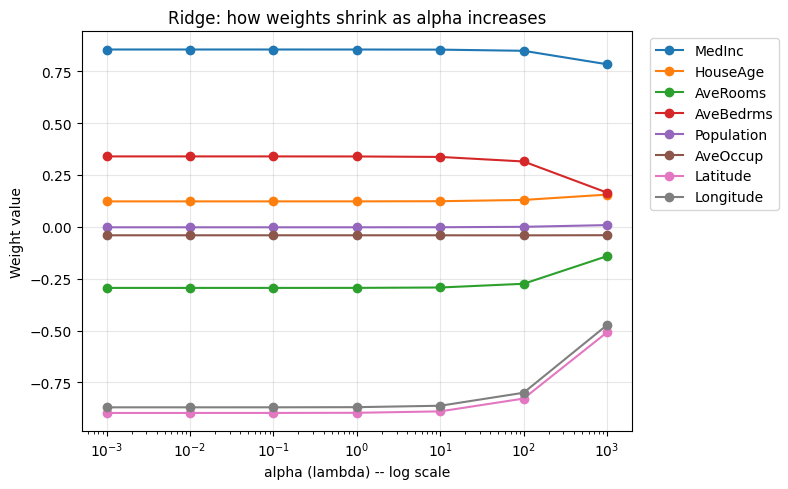

In [ ]:
plt.figure(figsize=(8,5))
for i, name in enumerate(data.feature_names):
    plt.plot(alphas, weights_over_alpha[:, i], 'o-', label=name)
plt.xscale('log')
plt.xlabel('alpha (lambda) -- log scale')
plt.ylabel('Weight value')
plt.title('Ridge: how weights shrink as alpha increases')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled, y_train)

print("Lasso Regression (alpha=0.1)")
print(f"  Train R2: {lasso.score(X_train_scaled, y_train):.4f}")
print(f"  Test  R2: {lasso.score(X_test_scaled,  y_test):.4f}")

pd.DataFrame({
    'feature': data.feature_names,
    'Linear weight': lr.coef_,
    'Ridge weight':  ridge.coef_,
    'Lasso weight':  lasso.coef_
})

Lasso Regression (alpha=0.1)
  Train R2: 0.4974
  Test  R2: 0.4814


,feature,Linear weight,Ridge weight,Lasso weight
0,MedInc,0.854383,0.854327,0.710598
1,HouseAge,0.122546,0.122624,0.106453
2,AveRooms,-0.294410,-0.294210,-0.000000
3,AveBedrms,0.339259,0.339008,0.000000
4,Population,-0.002308,-0.002282,-0.000000
5,AveOccup,-0.040829,-0.040833,-0.000000
6,Latitude,-0.896929,-0.896168,-0.011469
7,Longitude,-0.869842,-0.869071,-0.000000
